# Replacement Trap Analysis - Monte Carlo Sensitivity Analysis

This notebook performs Monte Carlo sensitivity analysis to test how price volatility and financing costs affect lifetime value outcomes.

**Dependencies:**
- Run `replacement_trap_core.ipynb` first to generate the DataFrame `df`
- Or load a saved DataFrame with all calculated metrics

**Methodology:**
- 1000 random scenarios with varying utility prices, HELOC rates, and lifespans (category-specific variance)
- Tests sensitivity to market conditions
- For dishwashers in replacement scenarios, only incremental energy/water savings are considered (labor savings cancel out)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import importlib
import textwrap

# Locate and add `lib` to path (shared with core notebook)
cwd = Path.cwd()
lib_dir = None

# Quick bootstrap to find lib (most common case first)
if (cwd.parent / 'lib' / 'replacement_trap_utils.py').exists() and cwd.name == 'analysis':
    lib_dir = cwd.parent / 'lib'
elif (cwd / 'lib' / 'replacement_trap_utils.py').exists():
    lib_dir = cwd / 'lib'
elif (cwd / 'notebooks' / 'lib' / 'replacement_trap_utils.py').exists():
    lib_dir = cwd / 'notebooks' / 'lib'
else:
    # Walk up to find lib directory
    for parent in [cwd] + list(cwd.parents):
        if (parent / 'lib' / 'replacement_trap_utils.py').exists():
            lib_dir = parent / 'lib'
            break

# Fallback: assume standard structure if we're in analysis/ directory
if lib_dir is None and cwd.name == 'analysis':
    potential_lib = cwd.parent / 'lib'
    if potential_lib.exists():
        lib_dir = potential_lib

if lib_dir is None:
    raise ImportError(
        f"Could not locate lib directory. Current working directory: {cwd}\n"
        f"Expected to find lib/replacement_trap_utils.py relative to notebooks root.\n"
        f"Please ensure you're running this notebook from the notebooks/analysis/ directory."
    )

if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

# Import utilities and config via shared helper
import replacement_trap_utils as rtu
rtu = importlib.reload(rtu)
get_notebooks_root = rtu.get_notebooks_root

from replacement_trap_utils import calculate_lifetime_value_heloc
from replacement_trap_config import (
    MONTE_CARLO_SCENARIOS,
    MONTE_CARLO_SEED,
    ELECTRICITY_MULTIPLIER_MIN,
    ELECTRICITY_MULTIPLIER_MAX,
    WATER_MULTIPLIER_MIN,
    WATER_MULTIPLIER_MAX,
    HELOC_RATE_MIN,
    HELOC_RATE_MAX,
    HELOC_LOAN_TERM,
    TIME_HORIZON,
    EFFICIENCY_DEGRADATION_RATE,
    ELECTRICITY_RATE,
    WATER_RATE,
    DISHWASHER_CYCLES_PER_YEAR,
    BASELINES,
    LIFESPAN_VARIANCE_BY_CATEGORY,
)

# Resolve notebooks root once and reuse
notebooks_root = get_notebooks_root()

# Set random seed for reproducibility
np.random.seed(MONTE_CARLO_SEED)

# Load DataFrame from core analysis
try:
    df  # Check if df already exists in memory
    print("✓ Using DataFrame from memory")
except NameError:
    print("⚠ DataFrame 'df' not found in memory. Attempting to load from disk...")
    df_save_path = notebooks_root / 'data' / 'replacement_trap_df.pkl'
    if df_save_path.exists():
        df = pd.read_pickle(df_save_path)
        print(f"✓ Loaded DataFrame from {df_save_path}")
    else:
        print(f"⚠ Saved DataFrame not found at {df_save_path}")
        print("  Please run replacement_trap_core.ipynb first to generate the DataFrame.")
        raise NameError("DataFrame 'df' is required. Please run replacement_trap_core.ipynb first.")

print(f"DataFrame shape: {df.shape}")



✓ Using DataFrame from memory
DataFrame shape: (11, 24)


## Monte Carlo Simulation

Generate random scenarios with varying electricity prices, water prices, HELOC rates, and lifespans.



In [12]:
# Generate random scenarios
n_scenarios = MONTE_CARLO_SCENARIOS

scenarios = []
for i in range(n_scenarios):
    scenarios.append({
        'elec_multiplier': np.random.uniform(ELECTRICITY_MULTIPLIER_MIN, ELECTRICITY_MULTIPLIER_MAX),
        'water_multiplier': np.random.uniform(WATER_MULTIPLIER_MIN, WATER_MULTIPLIER_MAX),
        'heloc_rate': np.random.uniform(HELOC_RATE_MIN, HELOC_RATE_MAX),
    })

print(f"Generated {len(scenarios)} scenarios")
print(f"Electricity multiplier range: {min(s['elec_multiplier'] for s in scenarios):.2f}x to {max(s['elec_multiplier'] for s in scenarios):.2f}x")
print(f"Water multiplier range: {min(s['water_multiplier'] for s in scenarios):.2f}x to {max(s['water_multiplier'] for s in scenarios):.2f}x")
print(f"HELOC rate range: {min(s['heloc_rate'] for s in scenarios)*100:.1f}% to {max(s['heloc_rate'] for s in scenarios)*100:.1f}%")



Generated 1000 scenarios
Electricity multiplier range: 0.50x to 3.00x
Water multiplier range: 1.00x to 9.99x
HELOC rate range: 6.0% to 12.0%


In [13]:
# Run Monte Carlo simulation for each system
results = []

for idx, system in df.iterrows():
    negative_count = 0
    
    # Get category-specific lifespan variance (lookup once per system)
    category = system['category']
    lifespan_variance = LIFESPAN_VARIANCE_BY_CATEGORY.get(category, 0.20)  # Default to 20% if category not found
    
    for scenario in scenarios:
        # Generate random lifespan multiplier for this scenario
        lifespan_multiplier = np.random.uniform(1.0 - lifespan_variance, 1.0 + lifespan_variance)
        scenario_lifespan = system['lifespan_years'] * lifespan_multiplier
        
        # Recalculate annual savings based on price multipliers
        # For dishwashers: energy + water costs affected, but labor savings unchanged
        if system['category'] == 'Dishwasher':
            # Recalculate baseline cost with new rates (old dishwasher)
            baseline_dw = BASELINES['Dishwasher']
            baseline_dw_kwh = baseline_dw['annual_kWh_point']
            baseline_dw_water_gal = baseline_dw['water_gal_per_cycle']
            
            baseline_energy_cost = baseline_dw_kwh * ELECTRICITY_RATE * scenario['elec_multiplier']
            baseline_water_cost = DISHWASHER_CYCLES_PER_YEAR * baseline_dw_water_gal * WATER_RATE * scenario['water_multiplier']
            baseline_operating_cost = baseline_energy_cost + baseline_water_cost
            
            # Recalculate new dishwasher costs with new rates
            new_energy_cost = system['annual_kwh'] * ELECTRICITY_RATE * scenario['elec_multiplier']
            new_water_cost = DISHWASHER_CYCLES_PER_YEAR * system.get('water_gal_per_cycle', 0) * WATER_RATE * scenario['water_multiplier']
            new_operating_cost = new_energy_cost + new_water_cost
            
            # Calculate energy/water savings (baseline - new)
            energy_water_savings = baseline_operating_cost - new_operating_cost
            
            # Note: In replacement scenario, labor savings are NOT incremental - both old and new dishwashers
            # provide identical labor benefits vs hand-washing, so labor savings cancel out.
            # Only energy/water savings are incremental when replacing an existing dishwasher.
            new_annual_savings = energy_water_savings
        else:
            # For other systems: scale energy savings by electricity multiplier
            # Use energy_savings_annual if available, otherwise calculate from annual_kwh
            if 'energy_savings_annual' in system:
                new_annual_savings = system['energy_savings_annual'] * scenario['elec_multiplier']
            else:
                # Approximate: scale by electricity multiplier
                new_annual_savings = system['annual_savings'] * scenario['elec_multiplier']
        
        # Recalculate 30-year lifetime value with new HELOC rate and varied lifespan
        heloc_flow, _ = calculate_lifetime_value_heloc(
            system['installed_cost'],
            new_annual_savings,
            scenario_lifespan,
            rate=scenario['heloc_rate'],
            loan_term=HELOC_LOAN_TERM,
            horizon=TIME_HORIZON,
            degradation_rate=EFFICIENCY_DEGRADATION_RATE
        )
        lifetime_value = heloc_flow[-1]  # Final year value
        
        if lifetime_value < 0:
            negative_count += 1
    
    results.append({
        'Model': system['model'],
        'Category': system['category'],
        'pct_negative_scenarios': (negative_count / n_scenarios) * 100
    })

mc_results = pd.DataFrame(results)
print(f"\n✓ Monte Carlo simulation complete for {len(df)} systems")




✓ Monte Carlo simulation complete for 11 systems


In [14]:
# Save Monte Carlo results for use in summary generation script
# Reuse notebooks_root from shared helper
mc_save_path = notebooks_root / 'data' / 'monte_carlo_results.pkl'
mc_results.to_pickle(mc_save_path)
print(f"✓ Monte Carlo results saved to {mc_save_path}")
print(f"  Shape: {mc_results.shape}")
print(f"  Systems analyzed: {len(mc_results)}")


✓ Monte Carlo results saved to c:\Users\grant\OneDrive\Documents\replacement_trap\data\monte_carlo_results.pkl
  Shape: (11, 3)
  Systems analyzed: 11


## Results Summary

Display and visualize Monte Carlo results.



In [15]:
# Display results
print("=" * 80)
print("MONTE CARLO RESULTS: % Scenarios with Negative Lifetime Value")
print("=" * 80)

# Sort by % negative scenarios (highest first)
mc_results_sorted = mc_results.sort_values('pct_negative_scenarios', ascending=False)

print("\nResults sorted by sensitivity (highest % negative scenarios first):\n")
print(mc_results_sorted.to_string(index=False))

print(f"\nSummary:")
print(f"  Systems with >50% negative scenarios: {(mc_results_sorted['pct_negative_scenarios'] > 50).sum()}/{len(mc_results_sorted)}")
print(f"  Average % negative scenarios: {mc_results_sorted['pct_negative_scenarios'].mean():.1f}%")
print(f"  Range: {mc_results_sorted['pct_negative_scenarios'].min():.1f}% to {mc_results_sorted['pct_negative_scenarios'].max():.1f}%")



MONTE CARLO RESULTS: % Scenarios with Negative Lifetime Value

Results sorted by sensitivity (highest % negative scenarios first):

                                                Model         Category  pct_negative_scenarios
                                 Miele G 7266 SCVi SF       Dishwasher                   100.0
                     Goodman GSX14 3-Ton Split System  Air Conditioner                   100.0
AO Smith Signature 100 Electric Water Heater (50 gal)     Water Heater                   100.0
              Blown-in cellulose insulation (to R-38) Attic Insulation                   100.0
            Trane XV18 Variable-Speed Air Conditioner  Air Conditioner                   100.0
          Mitsubishi Electric MUZ/MSZ-FS18 Mini-Split  Air Conditioner                   100.0
                        Stiebel Eltron Tempra 24 Plus     Water Heater                    96.3
                           Bosch 500 Series SHP65CM5N       Dishwasher                    89.0
             

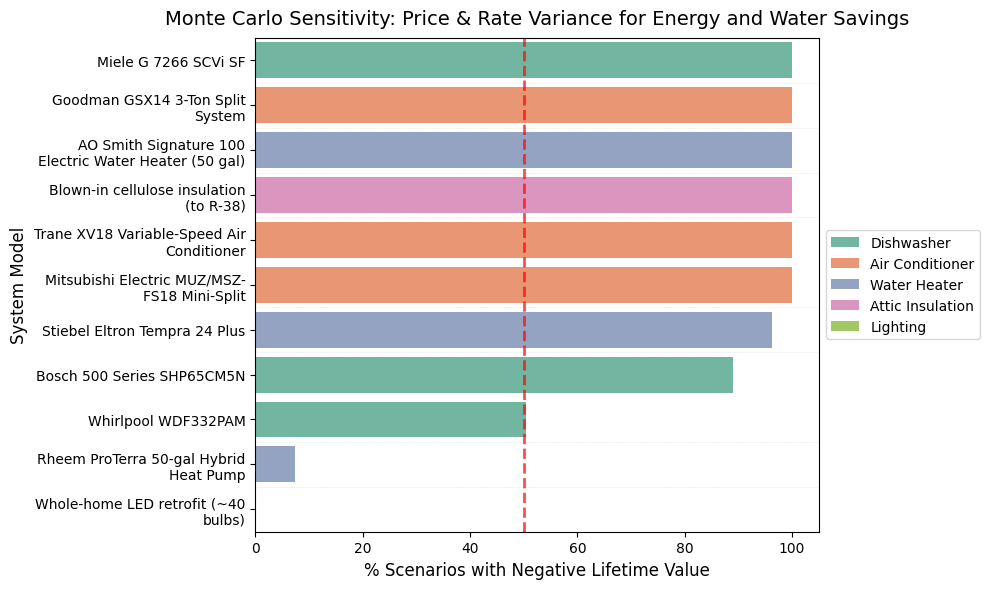


Visualization shows sensitivity to price/rate changes for 11 systems.
Higher % = more vulnerable to market conditions.
Note: Analysis considers energy & water savings only; comfort, resilience, and code compliance excluded.


In [23]:
# Visualization: Monte Carlo Results - Horizontal Bar Chart
# Ensure data is sorted by % negative scenarios (descending)
mc_results_viz = mc_results_sorted.copy().reset_index(drop=True)

# Identify category boundaries for dividers
category_boundaries = []
prev_category = None
for idx, row in mc_results_viz.iterrows():
    if prev_category is not None and row['Category'] != prev_category:
        category_boundaries.append(idx - 0.5)
    prev_category = row['Category']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=mc_results_viz, y='Model', x='pct_negative_scenarios',
                 hue='Category', palette='Set2', dodge=False)

# Add category dividers (very light horizontal lines)
for boundary in category_boundaries:
    ax.axhline(y=boundary, color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
# Add 50% reference line
plt.axvline(x=50, color='r', linestyle='--', linewidth=2, alpha=0.7)

plt.xlabel('% Scenarios with Negative Lifetime Value', fontsize=12)
plt.ylabel('System Model', fontsize=12)
plt.title('Monte Carlo Sensitivity: Price & Rate Variance for Energy and Water Savings', fontsize=14, pad=10)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

# Wrap y-axis labels using textwrap
ax = plt.gca()
tick_positions = ax.get_yticks()
tick_labels = ax.get_yticklabels()
wrapped_labels = [textwrap.fill(label.get_text(), width=30) for label in tick_labels]
ax.set_yticks(tick_positions)
ax.set_yticklabels(wrapped_labels)

plt.tight_layout()
plt.show()

print("\nVisualization shows sensitivity to price/rate changes for 11 systems.")
print("Higher % = more vulnerable to market conditions.")
print("Note: Analysis considers energy & water savings only; comfort, resilience, and code compliance excluded.")

